In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Baboon Image

Pixel max and min:
230 0
Number of unique pixel intensities in image:  226


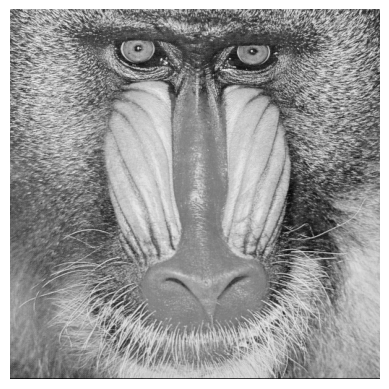

In [ ]:
# load image
import numpy as np
import scipy.io as sio

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/baboon.mat')['baboon']

# plot image
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')

print('Pixel max and min:')
print(img.max(), img.min())

uni = np.unique(img)
print('Number of unique pixel intensities in image: ',len(uni))

In [ ]:
import numpy as np
x = img.flatten()/255

# Uniform Quantizer



In [ ]:
import scipy.integrate as integrate
from scipy.stats import norm

def quantize_uniform(x, quant_min=0.0, quant_max=1.0, quant_level=8):
    """Uniform quantization approach

    Args:
        x (np.ndarray): Original signal
        quant_min (float): Minimum quantization level (Default value = 0.0)
        quant_max (float): Maximum quantization level (Default value = 1.0)
        quant_level (int): Number of quantization levels (Default value = 8)

    Returns:
        x_quant (np.ndarray): Quantized signal
    """
    x_normalize = (x-quant_min) * (quant_level-1) / (quant_max-quant_min)
    x_normalize[x_normalize > quant_level - 1] = quant_level - 1
    x_normalize[x_normalize < 0] = 0
    x_normalize_quant = np.around(x_normalize)
    x_quant = (x_normalize_quant) * (quant_max-quant_min) / (quant_level-1) + quant_min
    return x_quant

bit = 6
x_hat_q = quantize_uniform(x,quant_level=bit)

# Plot the quantized image

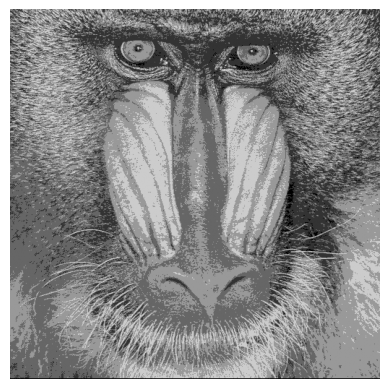

In [ ]:
img_hat = np.reshape(x_hat_q, img.shape)
plt.imshow(img_hat,cmap='gray')
plt.axis('off')

# SNR and MSE Evaluation

In [ ]:
import numpy as np

def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    sigma_n = np.var(err)
    sigma_s = np.var(actu)
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

# print SNR and MSE
print('SNR:', np.round(snr_dB(x, x_hat_q),6))
print('MSE:', np.round(MSE(x*255, x_hat_q*255), 6))

SNR: 8.75477
MSE: 238.33699
